# JobLens Vietnam — EDA

Nguồn: [TinixAI](https://huggingface.co/datasets/tinixai/vietnamese-job-descriptions), CC BY-NC 4.0. Bộ lọc IT/AI/Data dựa trên title. Chạy `python main.py --stage all` từ project để tạo toàn bộ kết quả. Notebook này tạo lại các bảng và biểu đồ EDA từ dữ liệu sạch.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
from IPython.display import display, Image, Markdown

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "configs/pipeline.json").exists() and (p / "main.py").exists()), None)
if ROOT is None:
    raise RuntimeError("Mở notebook trong thư mục project")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.utils import read_frame
from src.pipeline import load_config, run_pipeline
CONFIG = load_config(ROOT / "configs/pipeline.json")
if not (ROOT / "data/processed/jobs_cleaned.parquet").exists():
    run_pipeline("prepare")
jobs = read_frame(ROOT / "data/processed/jobs_cleaned.parquet")
print(f"{len(jobs):,} tin; {jobs.company_group.nunique():,} nhóm công ty")


14,034 tin; 5,868 nhóm công ty


## 1. Chất lượng dữ liệu

Giữ cột raw cùng cột đã xử lý để tra lại các quyết định. `Other` gồm nghề ngoài năm nhóm và title mơ hồ; không phải lỗi thiếu dữ liệu.

In [2]:
quality = json.loads((ROOT / "reports/data_quality.json").read_text(encoding="utf-8"))
display(pd.Series({k: v for k, v in quality.items() if not isinstance(v, dict)}, name="value"))
display(jobs[["job_title", "role_standard", "role_label_status", "salary", "salary_mean", "experience_level", "experience_min"]].head(12))
display(jobs.salary_parse_status.value_counts().rename("rows"))

input_rows                                                                  14034
cleaned_rows                                                                14034
duplicate_ids_removed                                                           0
duplicate_content_rows                                                       1254
salary_eligible_rows                                                        11859
classification_eligible_rows                                                 5352
experience_missing_rows                                                      1149
jobs_with_skills                                                             8695
usd_to_vnd_rate                                                             25500
limit                                                                        None
dataset_fingerprint             c3c030de43509edf2c5bed1e570577fb7240e5a4c8f83e...
Name: value, dtype: object

,job_title,role_standard,role_label_status,salary,salary_mean,experience_level,experience_min
0,Java Software Engineer - MSCV 233-2,Software Engineer,single,26 - 36 triệu,31000000.0,3 năm,3.0
1,Software Engineer (Backend/Frontend) - Tiếng T...,Software Engineer,single,15 - 35 triệu,25000000.0,Dưới 1 năm,0.0
2,"Lead Software Engineer – Desktop (Remote, Engl...",Software Engineer,single,4000 usd,102000000.0,5 năm,5.0
3,Lâp Trình Viên/ Software Engineer/ IT,Software Engineer,single,10 - 15 triệu,12500000.0,Không,NaN
4,Software Engineer (Fintech),Software Engineer,single,14 - 20 triệu,17000000.0,1 năm,1.0
5,Software Engineer (Fullstack Java/Reactjs),Software Engineer,single,1200 usd,30600000.0,Không,NaN
6,Software Tester (Automation & Manual),Other,unmapped,Đang cập nhật,NaN,1 năm,1.0
7,Lập Trình Nhúng-Embedded Software Engineer (C/...,Software Engineer,single,25 - 40 triệu,32500000.0,4 năm,4.0
8,Java Backend Developer (Banking),Software Engineer,single,Đang cập nhật,NaN,5 năm,5.0
9,"Middle Frontend (Thu Nhập 18-25tr/Tháng, Nguyễ...",Software Engineer,single,18 - 25 triệu,21500000.0,2 năm,2.0


salary_parse_status
parsed              11868
unknown_currency     1147
negotiable            835
invalid_range         175
no_amount               8
non_monthly             1
Name: rows, dtype: int64

## 2. Năm và nhóm nghề

`year` là năm từ nguồn, không có ngày/tháng. Độ phủ năm khác nhau và tin đăng lại khiến số dòng không đại diện cho tăng trưởng thị trường. Nhãn nghề tạo bằng quy tắc title, cần rà soát thủ công.

,role,jobs
0,Other,8682
1,Software Engineer,4271
2,Data Analyst,550
3,AI/ML Engineer,259
4,Data Engineer,175
5,Data Scientist,97


,year,jobs,median_salary_vnd,salary_rows
0,2022,2219,12500000.0,2213
1,2023,2428,12500000.0,2395
2,2024,2453,13500000.0,2404
3,2025,4178,15000000.0,3294
4,2026,2756,19000000.0,1553


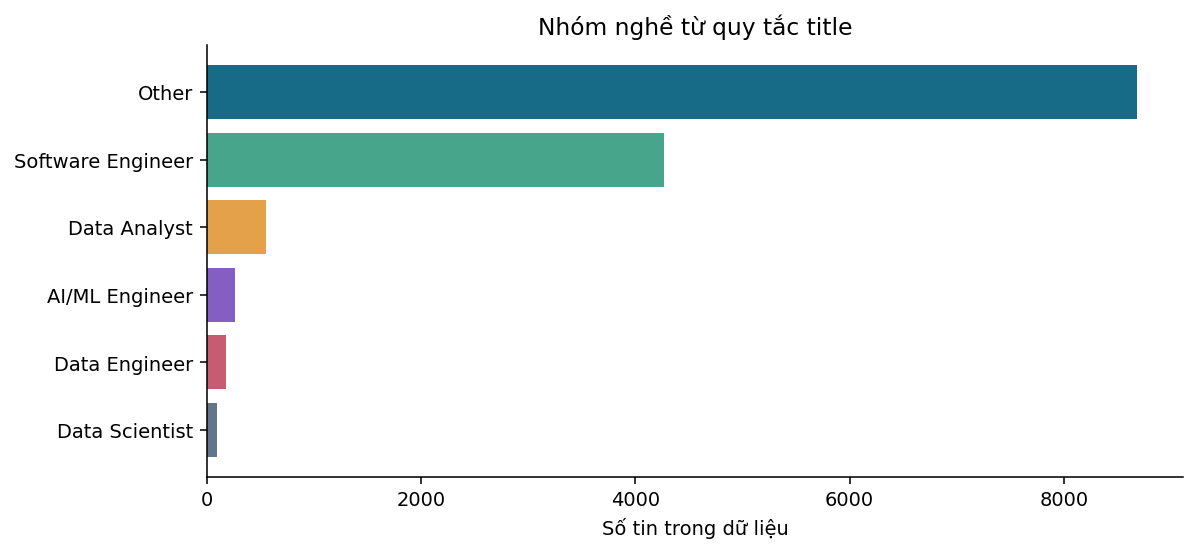

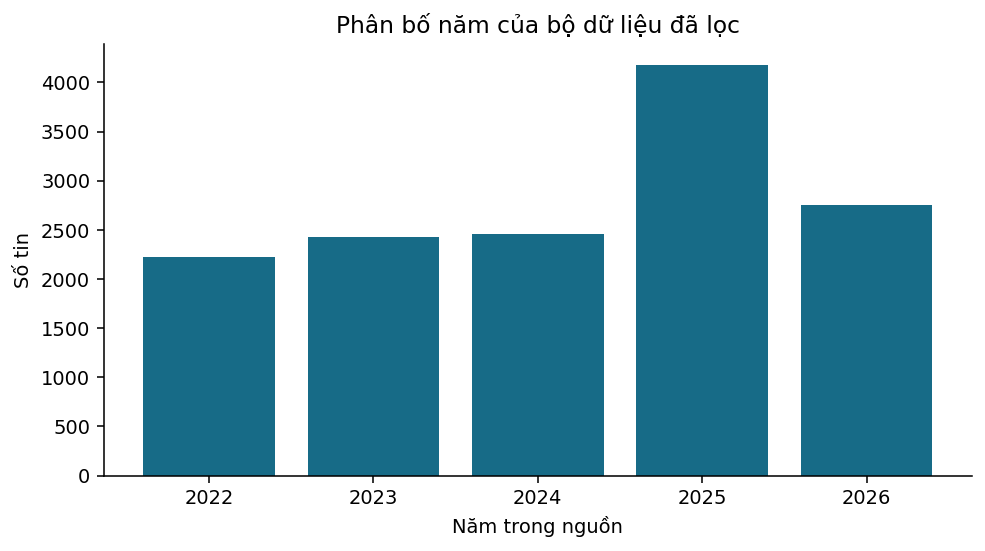

In [3]:
from src.reporting import generate_eda
tables = generate_eda(jobs)
display(tables["roles"])
display(tables["years"])
display(Image(filename=str(ROOT / "reports/figures/roles.png")))
display(Image(filename=str(ROOT / "reports/figures/years.png")))

## 3. Kỹ năng được đề cập

FlashText khớp alias theo ranh giới từ và loại trùng trong một JD. Số lần xuất hiện phản ánh việc **đề cập**, không phân biệt kỹ năng bắt buộc, ưu tiên hay phủ định. Các tên ngắn như R cần kiểm tra thêm ngữ cảnh.

,skill,jobs,share
0,JavaScript,2062,0.146929
1,SQL,2037,0.145147
2,Python,1822,0.129828
3,HTML,1748,0.124555
4,CSS,1729,0.123201
5,Git,1684,0.119994
6,MySQL,1548,0.110304
7,Java,1440,0.102608
8,Machine Learning,1411,0.100542
9,REST API,1378,0.098190


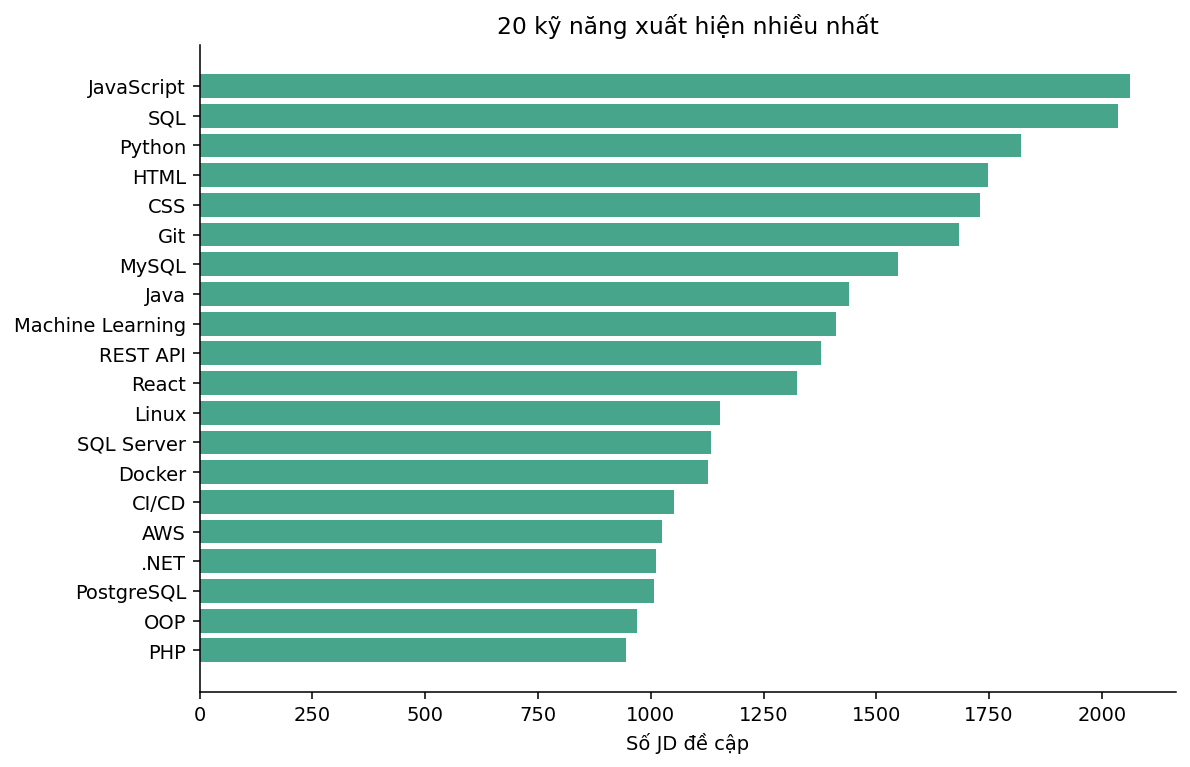

role_standard      role_standard      extracted_skills
AI/ML Engineer     AI/ML Engineer     Python               219
                                      Machine Learning     182
                                      PyTorch              165
                                      TensorFlow           154
                                      NLP                  116
                                      Deep Learning        113
                                      LLM                  110
                                      Computer Vision      104
Data Analyst       Data Analyst       SQL                  305
                                      Power BI             281
                                      Excel                275
                                      Python               199
                                      Tableau              161
                                      R                     95
                                      Machine Learning      84


In [4]:
display(tables["skills"].head(25))
display(Image(filename=str(ROOT / "reports/figures/skills.png")))
by_role = jobs[["role_standard", "extracted_skills"]].explode("extracted_skills").groupby(["role_standard", "extracted_skills"]).size().rename("jobs")
display(by_role.groupby(level=0).nlargest(8))

## 4. Midpoint lương và kinh nghiệm

Khoảng lương đóng dùng trung bình hai đầu, lương thỏa thuận/cận mở không được điền midpoint. USD dùng tỷ giá cấu hình cố định; chưa chuẩn hóa gross/net hoặc lạm phát. Boxplot ẩn điểm ngoại lệ để dễ đọc, bảng vẫn giữ toàn bộ midpoint hợp lệ. Kinh nghiệm dùng cận dưới của khoảng; giá trị `Không` đơn lẻ được để thiếu.

,role_standard,count,median,mean
0,AI/ML Engineer,150,30000000.0,2.961417e+07
1,Data Analyst,379,16000000.0,2.058061e+07
2,Data Engineer,95,24000000.0,2.430658e+07
3,Data Scientist,29,30000000.0,2.903879e+07
4,Other,7822,12500000.0,1.516840e+07
5,Software Engineer,3384,17500000.0,2.065066e+07


,count,median,mean
role_standard,,,
AI/ML Engineer,198,2.0,2.452020
Data Analyst,467,3.0,2.813704
Data Engineer,138,3.0,3.079710
Data Scientist,75,3.0,2.760000
Other,8203,3.0,2.708460
Software Engineer,3804,3.0,2.857716


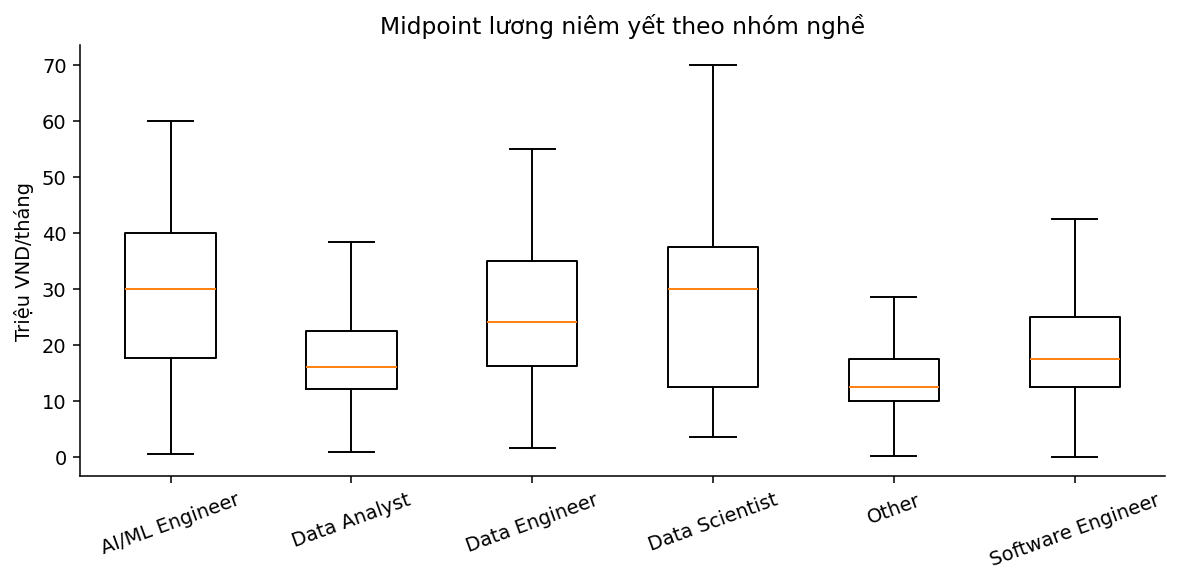

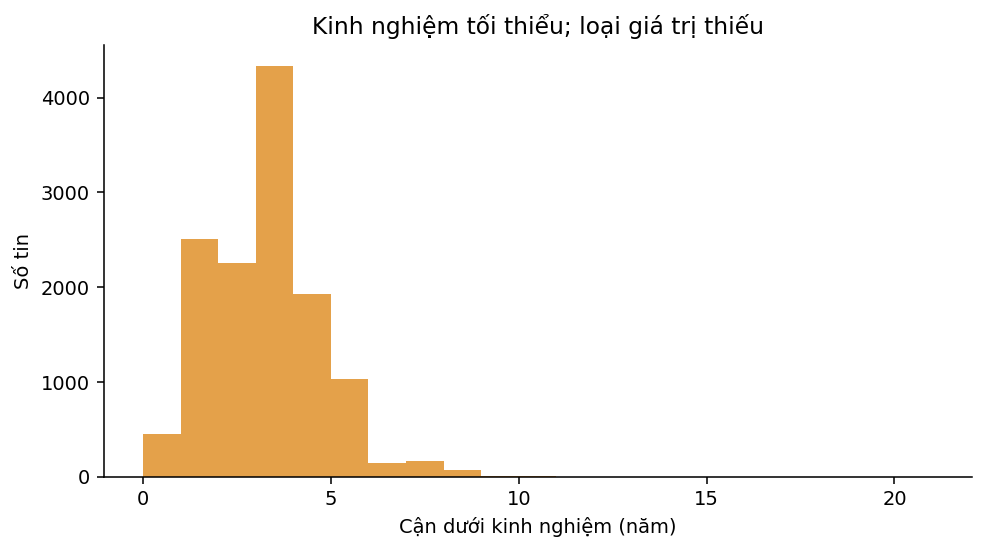

In [5]:
display(tables["salaries"])
display(jobs.groupby("role_standard").experience_min.agg(["count", "median", "mean"]))
display(Image(filename=str(ROOT / "reports/figures/salary_roles.png")))
display(Image(filename=str(ROOT / "reports/figures/experience.png")))

## 5. Rà soát các tin cần xem lại

Có thể sửa từ điển và quy tắc trong `configs/` và `src/preprocessing/`, rồi chạy lại pipeline. Dòng trùng nội dung được giữ cho EDA; mô hình chia theo nhóm công ty.

In [6]:
review = jobs.loc[jobs.role_label_status.eq("ambiguous") | jobs.duplicate_content,
                  ["id", "job_title", "company_name", "role_standard", "role_candidates", "duplicate_content"]]
display(review.head(30))
print("Mẫu gán nhãn thủ công:", ROOT / "reports/annotation_template.csv")

,id,job_title,company_name,role_standard,role_candidates,duplicate_content
51,129,"Data Engineer and Integrations Lead ( Azure, S...",MITEK VIET NAM,Other,"[Data Analyst, Data Engineer]",False
52,131,[Online] Công Ty Springer Capital Tuyển Dụng T...,ISAAC ANDREW,Other,"[Data Scientist, Data Engineer, AI/ML Engineer...",False
69,164,[Online] Công Ty Cybergate Shields Tuyển Dụng ...,CYBERGATE SHIELDS,Other,"[AI/ML Engineer, Software Engineer]",False
366,1570,Trung tâm Quản trị và phân tích dữ liệu - Chuy...,NGÂN HÀNG TMCP PHƯƠNG ĐÔNG (OCB),Other,"[Data Analyst, Data Scientist]",False
382,1648,Kỹ sư AI/ Kỹ sư Fullstack - công ty IT Nhật mới,CÔNG TY TNHH JOB HOUSE,Other,"[AI/ML Engineer, Software Engineer]",False
448,3876,Data Engineer / Software Developer,CÔNG TY TNHH HANESBRANDS VIỆT NAM HUẾ,Other,"[Data Engineer, Software Engineer]",False
1105,4567,"Lead Data Engineer (Azure, SQL, Power BI)",CÔNG TY TNHH MITEK VIỆT NAM,Other,"[Data Analyst, Data Engineer]",False
1110,4573,"Lead Data Engineer (Azure, SQL, Power BI, Engl...",CÔNG TY TNHH MITEK VIỆT NAM,Other,"[Data Analyst, Data Engineer]",False
1134,4610,Data Analyst & Data Scientist,NGÂN HÀNG TMCP TIÊN PHONG | TPBANK,Other,"[Data Analyst, Data Scientist]",False
1186,4662,[HN] Công Ty Biotech Nanyang Biologics Tuyển D...,LINH TRAN KHANH,Other,"[AI/ML Engineer, Software Engineer]",False


Mẫu gán nhãn thủ công: G:\hoc_tap\IntroDS\project_intro_ds\reports\annotation_template.csv
